# Frozen Baseline Evaluation: AbLangRBD1 vs AntiBERTy vs ESM-2

Compare the pretrained/fine-tuned AbLangRBD1 embeddings against frozen AntiBERTy and ESM-2 baselines on the SARS-CoV-2 RBD epitope pair-classification task.

**Evaluation:** For each model, we embed test-set antibodies, compute all pairwise cosine similarities, then measure AUROC and average precision for distinguishing same-epitope pairs from different-epitope pairs.

In [1]:
import sys, os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from sklearn.manifold import TSNE

# Make ablang_model/Inference importable
sys.path.insert(0, os.path.join(os.pardir, "ablang_model", "Inference"))

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


## 1. Load Data and Select Test Set

In [2]:
df_full = pd.read_pickle(os.path.join(os.pardir, "ablang_model", "train", "rbd_dataset.pd"))

# data_embedded_epoch_280.pd has the fine-tuned AbLangRBD1 embeddings
df_finetuned = pd.read_pickle(os.path.join(os.pardir, "ablang_model", "train", "data_embedded_epoch_280.pd"))

# Use the existing TEST split (uppercase labels from Holt pipeline)
df_test = df_full[df_full["DATASET"] == "TEST"].copy().reset_index(drop=True)
df_test_finetuned = df_finetuned[df_finetuned["DATASET"] == "TEST"].copy().reset_index(drop=True)
print(f"Test set size: {len(df_test)}")
print(f"Epitopes in test set:\n{df_test['EPITOPE'].value_counts().sort_index()}")

# Build integer labels for the test set epitopes
epitope_list = sorted(df_test["EPITOPE"].unique())
epitope_to_idx = {ep: i for i, ep in enumerate(epitope_list)}
labels = np.array([epitope_to_idx[ep] for ep in df_test["EPITOPE"]])
print(f"\n{len(epitope_list)} epitope classes: {epitope_list}")

Test set size: 307
Epitopes in test set:
EPITOPE
A       22
B       16
C       22
D1      18
D2       9
E1      10
E2.1    18
E2.2    54
E3      50
F1      46
F2      32
F3      10
Name: count, dtype: int64

12 epitope classes: ['A', 'B', 'C', 'D1', 'D2', 'E1', 'E2.1', 'E2.2', 'E3', 'F1', 'F2', 'F3']


## 2. AbLang Embeddings

We load two sets of pre-computed AbLang embeddings:
- **AbLang (frozen):** pretrained embeddings from `rbd_dataset.pd` (no fine-tuning)
- **AbLangRBD1 (fine-tuned):** embeddings from epoch 280 checkpoint in `data_embedded_epoch_280.pd`

In [3]:
# Frozen pretrained AbLang (from rbd_dataset.pd — no contrastive fine-tuning)
ablang_frozen_embeddings = torch.tensor(np.stack(df_test["EMBEDDING"].values), dtype=torch.float32)
ablang_frozen_embeddings = F.normalize(ablang_frozen_embeddings, dim=1)
print(f"AbLang (frozen) embeddings shape: {ablang_frozen_embeddings.shape}")

# Fine-tuned AbLangRBD1 (epoch 280 contrastive checkpoint)
ablang_finetuned_embeddings = torch.tensor(np.stack(df_test_finetuned["EMBEDDING"].values), dtype=torch.float32)
ablang_finetuned_embeddings = F.normalize(ablang_finetuned_embeddings, dim=1)
print(f"AbLangRBD1 (fine-tuned) embeddings shape: {ablang_finetuned_embeddings.shape}")

AbLang (frozen) embeddings shape: torch.Size([307, 1536])
AbLangRBD1 (fine-tuned) embeddings shape: torch.Size([307, 1536])


## 3. AntiBERTy Embeddings (Frozen, Heavy Chain Only)

Following Holt et al., we use only the heavy chain through the pretrained AntiBERTy model with no fine-tuning. Per-residue outputs are mean-pooled and L2-normalized.

In [4]:
import transformers

ANTIBERTY_DIR = "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/antiberty/trained_models"
ANTIBERTY_CKPT = f"{ANTIBERTY_DIR}/AntiBERTy_md_smooth"
ANTIBERTY_VOCAB = f"{ANTIBERTY_DIR}/vocab.txt"

antiberty_tokenizer = transformers.BertTokenizer(vocab_file=ANTIBERTY_VOCAB, do_lower_case=False)

antiberty_config = transformers.BertConfig.from_pretrained(ANTIBERTY_CKPT)
antiberty_model = transformers.BertModel(antiberty_config)
state_dict = torch.load(f"{ANTIBERTY_CKPT}/pytorch_model.bin", map_location="cpu", weights_only=False)
antiberty_model.load_state_dict(state_dict, strict=False)
antiberty_model = antiberty_model.to(device).eval()
print(f"AntiBERTy loaded — {sum(p.numel() for p in antiberty_model.parameters())/1e6:.1f}M params")

heavy_seqs = df_test["HC_AA"].tolist()

BATCH = 32
all_embeds = []
for i in range(0, len(heavy_seqs), BATCH):
    batch_seqs = [" ".join(list(seq)) for seq in heavy_seqs[i : i + BATCH]]
    tokens = antiberty_tokenizer(batch_seqs, return_tensors="pt", padding=True, truncation=True, max_length=512)
    tokens = {k: v.to(device) for k, v in tokens.items()}
    with torch.no_grad():
        out = antiberty_model(**tokens)
    mask = tokens["attention_mask"].unsqueeze(-1).float()
    mean_pooled = (out.last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1)
    all_embeds.append(mean_pooled.cpu())
    if (i // BATCH) % 5 == 0:
        print(f"  AntiBERTy batch {i // BATCH + 1}/{(len(heavy_seqs) + BATCH - 1) // BATCH}")

antiberty_embeddings = F.normalize(torch.cat(all_embeds, dim=0), dim=1)
print(f"AntiBERTy embeddings shape: {antiberty_embeddings.shape}")

del antiberty_model
torch.cuda.empty_cache() if torch.cuda.is_available() else None

AntiBERTy loaded — 25.8M params
  AntiBERTy batch 1/10
  AntiBERTy batch 6/10
AntiBERTy embeddings shape: torch.Size([307, 512])


## 4. ESM-2 Embeddings (Frozen, Heavy Chain Only)

We use ESM-2 (`esm2_t33_650M_UR50D`) with no fine-tuning. Heavy-chain sequences are tokenized, mean-pooled over non-padding positions, and L2-normalized.

> **Tip:** If running on a memory-constrained machine, swap the model ID for `facebook/esm2_t6_8M_UR50D` (8M params) — the directional comparison will still be valid.

In [5]:
from transformers import AutoTokenizer, AutoModel

ESM_MODEL_ID = "facebook/esm2_t33_650M_UR50D"

esm_tokenizer = AutoTokenizer.from_pretrained(ESM_MODEL_ID)
esm_model = AutoModel.from_pretrained(ESM_MODEL_ID).to(device).eval()

heavy_seqs = df_test["HC_AA"].tolist()

BATCH = 8
all_embeds = []
for i in range(0, len(heavy_seqs), BATCH):
    batch_seqs = heavy_seqs[i : i + BATCH]
    tokens = esm_tokenizer(batch_seqs, return_tensors="pt", padding=True, truncation=True, max_length=512)
    tokens = {k: v.to(device) for k, v in tokens.items()}
    with torch.no_grad():
        out = esm_model(**tokens)
    mask = tokens["attention_mask"].unsqueeze(-1).float()
    mean_pooled = (out.last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1)
    all_embeds.append(mean_pooled.cpu())
    if (i // BATCH) % 5 == 0:
        print(f"  ESM-2 batch {i // BATCH + 1}/{(len(heavy_seqs) + BATCH - 1) // BATCH}")

esm_embeddings = F.normalize(torch.cat(all_embeds, dim=0), dim=1)
print(f"ESM-2 embeddings shape: {esm_embeddings.shape}")

del esm_model, esm_tokenizer
torch.cuda.empty_cache() if torch.cuda.is_available() else None

Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ESM-2 batch 1/39
  ESM-2 batch 6/39
  ESM-2 batch 11/39
  ESM-2 batch 16/39
  ESM-2 batch 21/39
  ESM-2 batch 26/39
  ESM-2 batch 31/39
  ESM-2 batch 36/39
ESM-2 embeddings shape: torch.Size([307, 1280])


## 5. Build Pair Labels and Evaluate

For every pair of test antibodies we ask: do they share the same epitope? Cosine similarity is the predictor; the binary same/different label is the ground truth. We compute AUROC and Average Precision for each model.

In [6]:
def build_pair_scores(embeddings, labels):
    """Return flattened upper-triangle cosine sims and binary same-epitope labels."""
    cos_sim = embeddings @ embeddings.T
    n = len(labels)
    triu_idx = torch.triu_indices(n, n, offset=1)
    y_score = cos_sim[triu_idx[0], triu_idx[1]].numpy()
    y_true = (labels[triu_idx[0].numpy()] == labels[triu_idx[1].numpy()]).astype(int)
    return y_score, y_true

model_embeddings = {
    "AbLangRBD1 (fine-tuned)": ablang_finetuned_embeddings,
    "AbLang (frozen)": ablang_frozen_embeddings,
    "AntiBERTy (frozen)": antiberty_embeddings,
    "ESM-2 (frozen)": esm_embeddings,
}

results = {}
pair_data = {}
for name, emb in model_embeddings.items():
    y_score, y_true = build_pair_scores(emb, labels)
    auroc = roc_auc_score(y_true, y_score)
    avg_prec = average_precision_score(y_true, y_score)
    results[name] = {"AUROC": auroc, "Avg. Precision": avg_prec}
    pair_data[name] = (y_score, y_true)
    print(f"{name:30s}  AUROC={auroc:.3f}  AvgPrec={avg_prec:.3f}")

results_df = pd.DataFrame(results).T
results_df

AbLangRBD1 (fine-tuned)         AUROC=0.812  AvgPrec=0.533
AbLang (frozen)                 AUROC=0.587  AvgPrec=0.186
AntiBERTy (frozen)              AUROC=0.541  AvgPrec=0.135
ESM-2 (frozen)                  AUROC=0.547  AvgPrec=0.150


,AUROC,Avg. Precision
AbLangRBD1 (fine-tuned),0.811841,0.532569
AbLang (frozen),0.586572,0.185500
AntiBERTy (frozen),0.541040,0.135217
ESM-2 (frozen),0.546806,0.149596


## 6. Figure 1 — ROC Curves

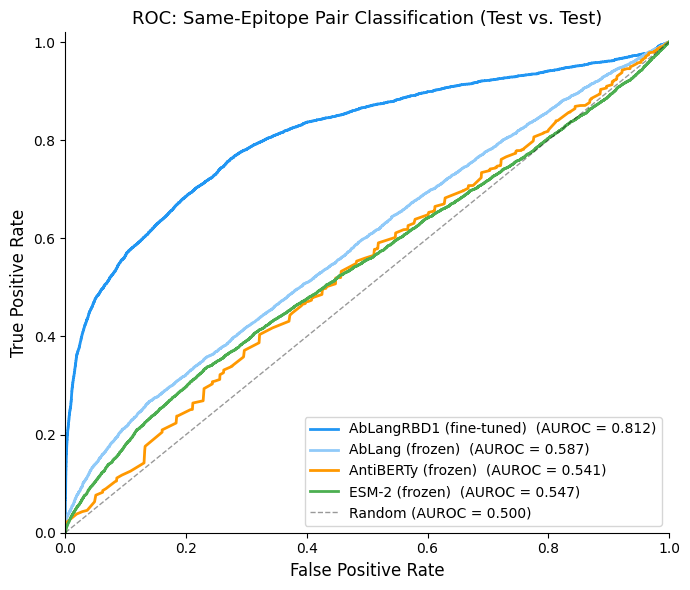

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))

colors = {
    "AbLangRBD1 (fine-tuned)": "#2196F3",
    "AbLang (frozen)": "#90CAF9",
    "AntiBERTy (frozen)": "#FF9800",
    "ESM-2 (frozen)": "#4CAF50",
}

for name, (y_score, y_true) in pair_data.items():
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auroc = results[name]["AUROC"]
    ax.plot(fpr, tpr, label=f"{name}  (AUROC = {auroc:.3f})", color=colors[name], lw=2)

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4, label="Random (AUROC = 0.500)")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC: Same-Epitope Pair Classification (Test vs. Test)", fontsize=13)
ax.legend(fontsize=10, loc="lower right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
sns.despine()
fig.tight_layout()
fig.savefig(os.path.join(os.pardir, "results", "frozen_fixed", "roc_baseline_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

## 7. Figure 2 — t-SNE Visualization (3 Panels)

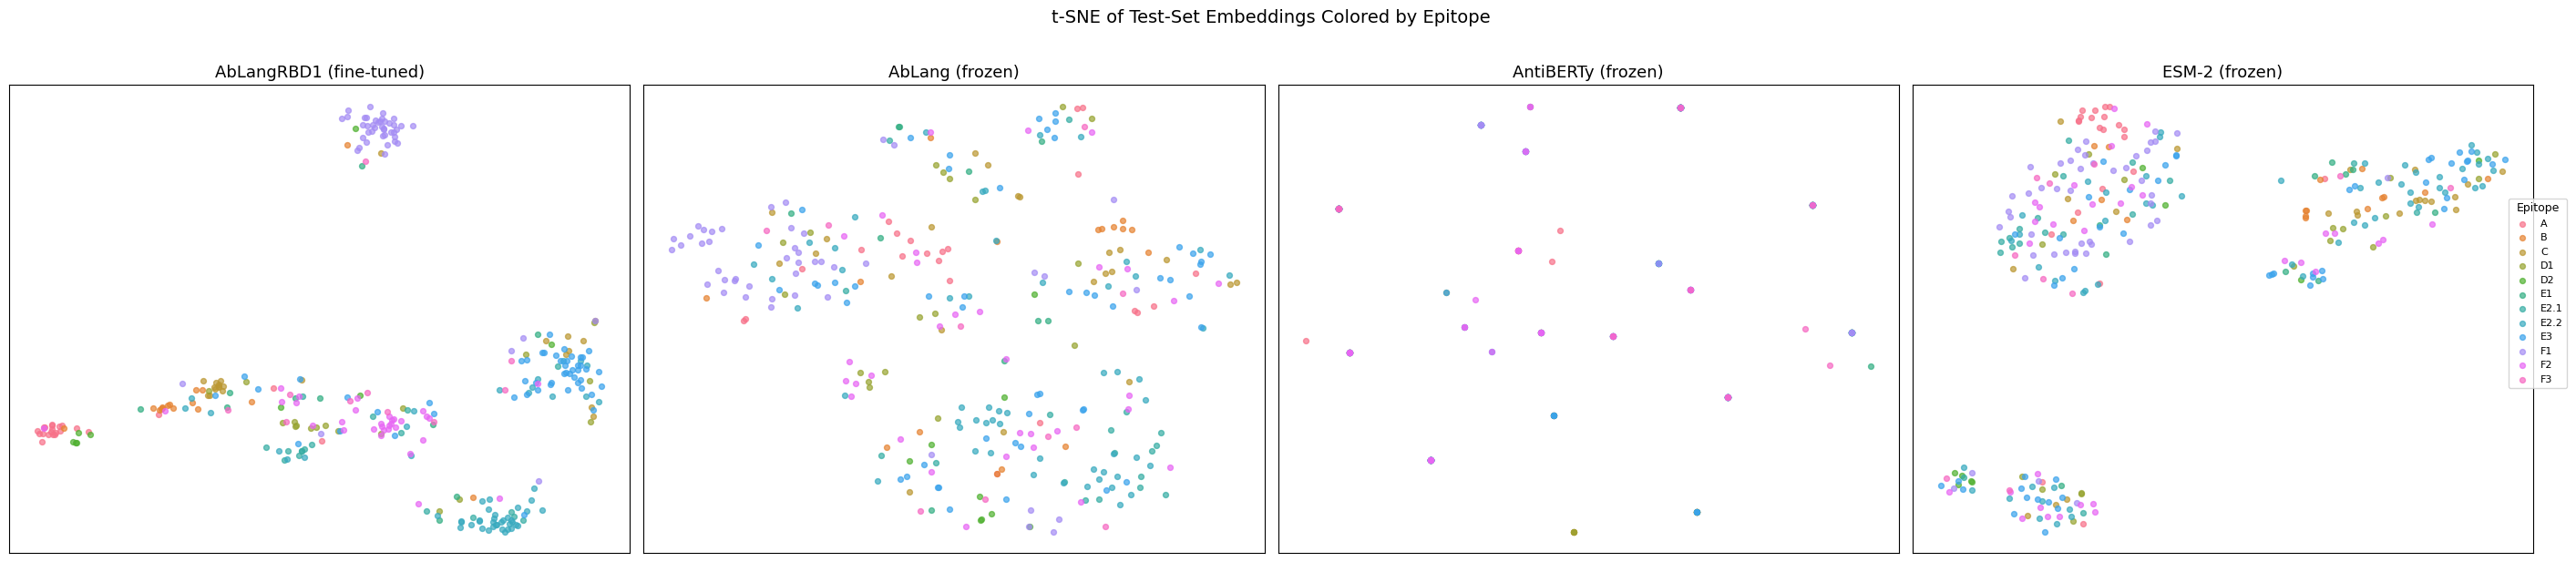

In [11]:
epitope_labels_str = df_test["EPITOPE"].values
unique_epitopes = sorted(set(epitope_labels_str))
palette = dict(zip(unique_epitopes, sns.color_palette("husl", len(unique_epitopes))))

n_models = len(model_embeddings)
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 6))

for ax, (name, emb) in zip(axes, model_embeddings.items()):
    tsne = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto", random_state=42)
    coords = tsne.fit_transform(emb.numpy())

    for ep in unique_epitopes:
        mask = epitope_labels_str == ep
        ax.scatter(coords[mask, 0], coords[mask, 1], s=18, alpha=0.7, label=ep, color=palette[ep])

    ax.set_title(name, fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])

handles, lbls = axes[0].get_legend_handles_labels()
fig.legend(handles, lbls, loc="center right", fontsize=8, title="Epitope", title_fontsize=9,
           bbox_to_anchor=(1.01, 0.5), ncol=1)
fig.suptitle("t-SNE of Test-Set Embeddings Colored by Epitope", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(os.pardir, "results", "frozen_fixed", "tsne_baseline_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

## 8. Figure 3 — Cosine Similarity Distributions (Same vs. Different Epitope)

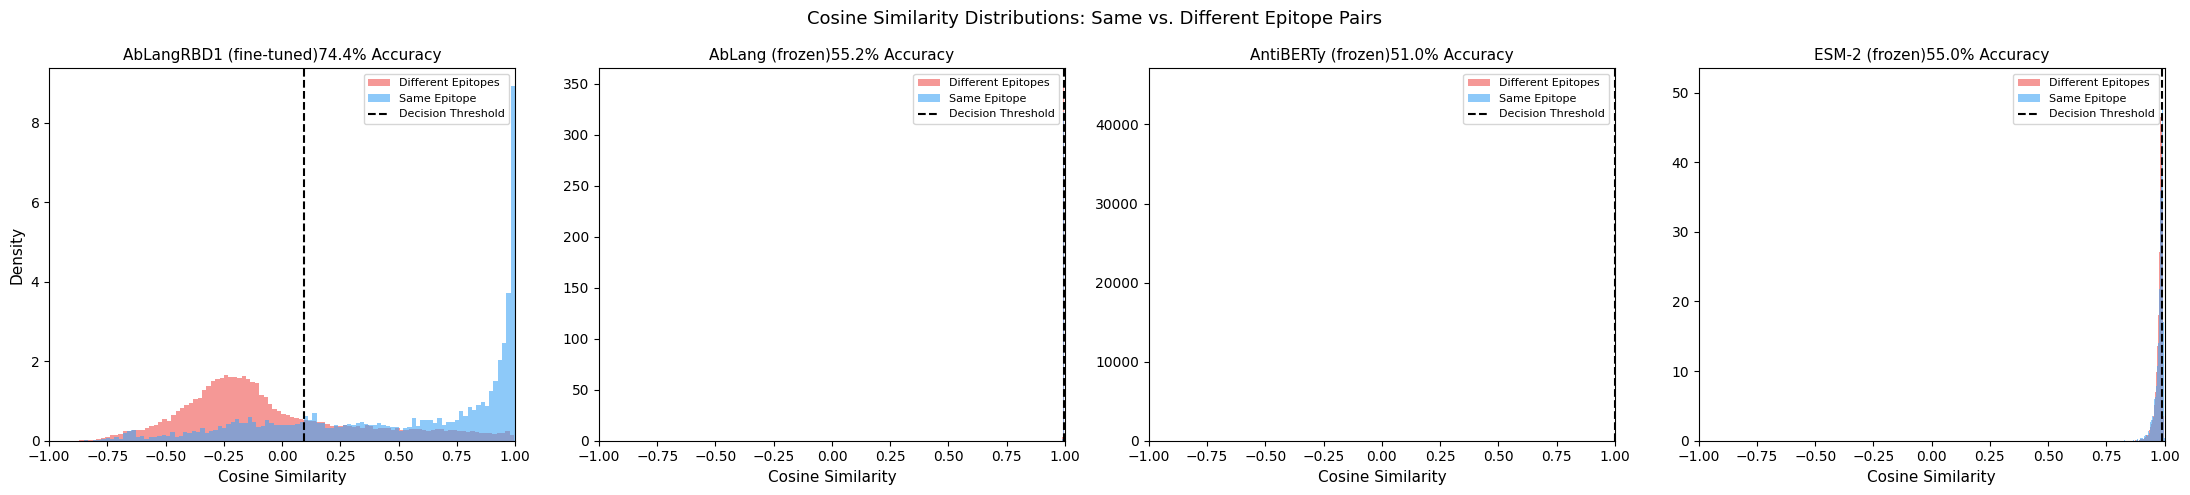

Saved → ../results/frozen/cosine_distributions_baseline.png


In [ ]:
from sklearn.metrics import balanced_accuracy_score

n_models = len(pair_data)
fig, axes = plt.subplots(1, n_models, figsize=(5.5 * n_models, 5), sharey=False)

for ax, (name, (y_score, y_true)) in zip(axes, pair_data.items()):
    same_ep = y_score[y_true == 1]
    diff_ep = y_score[y_true == 0]

    ax.hist(diff_ep, bins=100, alpha=0.6, density=True, label="Different Epitopes", color="#EF5350")
    ax.hist(same_ep, bins=100, alpha=0.6, density=True, label="Same Epitope", color="#42A5F5")

    # Find best threshold (maximise balanced accuracy) — mirrors Holt et al. protocol
    best_thresh, best_bacc = 0.0, -1.0
    for t in np.linspace(-1, 1, 1001):
        bacc = balanced_accuracy_score(y_true, y_score > t)
        if bacc > best_bacc:
            best_bacc, best_thresh = bacc, t

    ax.axvline(best_thresh, color="black", linestyle="--", linewidth=1.5,
               label="Decision Threshold")
    ax.set_title(f"{name}{best_bacc*100:.1f}% Accuracy", fontsize=11)
    ax.set_xlabel("Cosine Similarity", fontsize=11)
    ax.set_xlim(-1, 1)          # shared x-axis matching Holt et al. Fig 3A
    ax.legend(fontsize=8)

axes[0].set_ylabel("Density", fontsize=11)
fig.suptitle("Cosine Similarity Distributions: Same vs. Different Epitope Pairs", fontsize=13)
fig.tight_layout()
out_path = os.path.join(os.pardir, "results", "frozen_fixed", "cosine_distributions_baseline.png")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")

## 9. Summary

In [15]:
from IPython.display import Markdown

header = "| Model | AUROC | Avg. Precision |\n|---|---|---|\n"
rows = ""
for name, metrics in results.items():
    rows += f"| {name} | {metrics['AUROC']:.3f} | {metrics['Avg. Precision']:.3f} |\n"

display(Markdown(header + rows))

print(f"\nTest set: {len(df_test)} antibodies, {len(epitope_list)} epitope classes")
print(f"Total pairs evaluated: {len(pair_data[list(pair_data.keys())[0]][0]):,}")

| Model | AUROC | Avg. Precision |
|---|---|---|
| AbLangRBD1 (fine-tuned) | 0.812 | 0.533 |
| AbLang (frozen) | 0.587 | 0.186 |
| AntiBERTy (frozen) | 0.541 | 0.135 |
| ESM-2 (frozen) | 0.547 | 0.150 |



Test set: 307 antibodies, 12 epitope classes
Total pairs evaluated: 46,971


## 10. Re-Evaluation with Holt et al. Per-Epitope Weighted AUROC

The evaluation above used `sklearn.roc_auc_score` (global binary AUROC over all pairs, test-vs-test only). The fine-tuned model evaluation in `src/evaluate.py` uses the **per-epitope weighted AUROC** from Holt et al., which:

1. Computes TPR/FPR curves **independently for each epitope class**
2. Weights each curve by the epitope's proportion of positive pairs
3. Reports both **train-vs-test** (primary) and **test-vs-test** modes
4. Selects a cosine threshold on **train-vs-val** for F1 / balanced accuracy

To enable a fair frozen-vs-finetuned comparison, we re-evaluate below using the identical protocol.

In [28]:
sys.path.insert(0, os.path.join(os.pardir, "src"))
from evaluate import (
    get_cross_dataset_weighted_rocauc,
    evaluate_embedding_sets,
    find_threshold_on_val,
    evaluate_pair_mode,
    plot_tsne,
    plot_cosine_distributions,
    _binary_pair_scores,
)
from data_loader import MAIN_EPITOPES

epitope_to_idx = {ep: i for i, ep in enumerate(MAIN_EPITOPES)}

df_train = df_full[df_full["DATASET"] == "TRAIN"].copy().reset_index(drop=True)
df_val   = df_full[df_full["DATASET"] == "VAL"].copy().reset_index(drop=True)

train_labels = np.array([epitope_to_idx[ep] for ep in df_train["EPITOPE"]])
val_labels   = np.array([epitope_to_idx[ep] for ep in df_val["EPITOPE"]])
# test labels reuse `labels` from cell 2

print(f"TRAIN: {len(df_train)}  VAL: {len(df_val)}  TEST: {len(df_test)}")
print(f"Epitope classes: {len(MAIN_EPITOPES)}")

TRAIN: 2465  VAL: 269  TEST: 307
Epitope classes: 12


### 10a. Embed Train & Val Splits — AntiBERTy (frozen)

In [29]:
def embed_antiberty(sequences, batch_size=32, max_length=512):
    """Mean-pool + L2-normalize AntiBERTy heavy-chain embeddings."""
    tokenizer = transformers.BertTokenizer(vocab_file=ANTIBERTY_VOCAB, do_lower_case=False)
    config = transformers.BertConfig.from_pretrained(ANTIBERTY_CKPT)
    model = transformers.BertModel(config)
    state = torch.load(f"{ANTIBERTY_CKPT}/pytorch_model.bin", map_location="cpu", weights_only=False)
    model.load_state_dict(state, strict=False)
    model = model.to(device).eval()

    all_embeds = []
    for i in range(0, len(sequences), batch_size):
        batch_seqs = [" ".join(list(s)) for s in sequences[i : i + batch_size]]
        tokens = tokenizer(batch_seqs, return_tensors="pt", padding=True, truncation=True, max_length=max_length)
        tokens = {k: v.to(device) for k, v in tokens.items()}
        with torch.no_grad():
            out = model(**tokens)
        mask = tokens["attention_mask"].unsqueeze(-1).float()
        mean_pooled = (out.last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1)
        all_embeds.append(mean_pooled.cpu())
    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    return F.normalize(torch.cat(all_embeds, dim=0), dim=1)

ab_train_emb = embed_antiberty(df_train["HC_AA"].tolist())
ab_val_emb   = embed_antiberty(df_val["HC_AA"].tolist())
ab_test_emb  = antiberty_embeddings  # reuse from cell 3

print(f"AntiBERTy  train {ab_train_emb.shape}  val {ab_val_emb.shape}  test {ab_test_emb.shape}")

AntiBERTy  train torch.Size([2465, 512])  val torch.Size([269, 512])  test torch.Size([307, 512])


### 10b. Embed Train & Val Splits — ESM-2 (frozen)

In [30]:
def embed_esm2(sequences, batch_size=8, max_length=512):
    """Mean-pool + L2-normalize ESM-2 heavy-chain embeddings."""
    tokenizer = AutoTokenizer.from_pretrained(ESM_MODEL_ID)
    model = AutoModel.from_pretrained(ESM_MODEL_ID).to(device).eval()

    all_embeds = []
    for i in range(0, len(sequences), batch_size):
        batch_seqs = sequences[i : i + batch_size]
        tokens = tokenizer(batch_seqs, return_tensors="pt", padding=True, truncation=True, max_length=max_length)
        tokens = {k: v.to(device) for k, v in tokens.items()}
        with torch.no_grad():
            out = model(**tokens)
        mask = tokens["attention_mask"].unsqueeze(-1).float()
        mean_pooled = (out.last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1)
        all_embeds.append(mean_pooled.cpu())
    del model, tokenizer
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    return F.normalize(torch.cat(all_embeds, dim=0), dim=1)

esm_train_emb = embed_esm2(df_train["HC_AA"].tolist())
esm_val_emb   = embed_esm2(df_val["HC_AA"].tolist())
esm_test_emb  = esm_embeddings  # reuse from cell 4

print(f"ESM-2  train {esm_train_emb.shape}  val {esm_val_emb.shape}  test {esm_test_emb.shape}")

Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ESM-2  train torch.Size([2465, 1280])  val torch.Size([269, 1280])  test torch.Size([307, 1280])


### 10c. Run Full Holt et al. Evaluation Protocol & Save Results


Evaluating: ablang_frozen


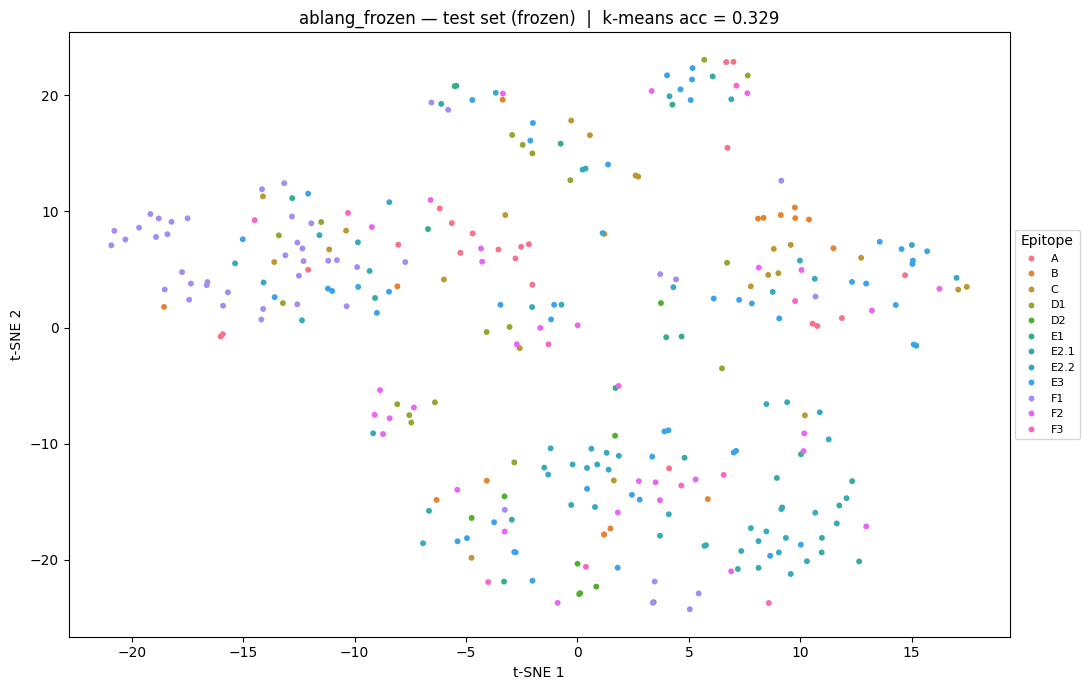

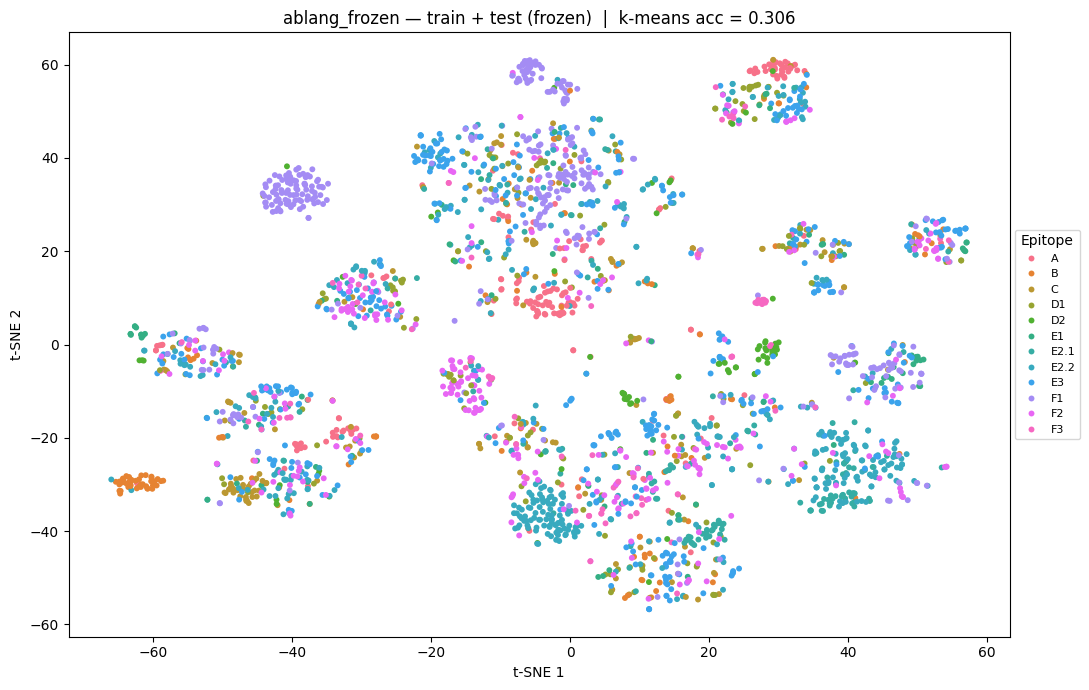

Saved → ../results/frozen_fixed/ablang_frozen_cosine_distributions.png


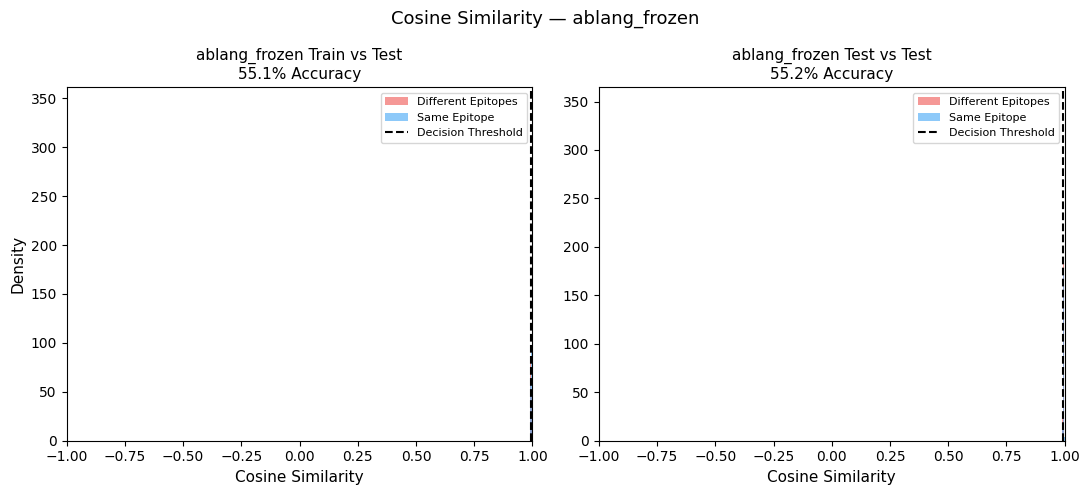

Saved → ../results/frozen_fixed/ablang_frozen_final_eval.json
{
  "val_threshold": 0.994,
  "train_vs_test": {
    "average_precision": 0.1866931968604201,
    "f1": 0.21713166191055444,
    "balanced_accuracy": 0.5507874154608515,
    "threshold": 0.994,
    "weighted_auroc": 0.5610707247017456
  },
  "test_vs_test": {
    "average_precision": 0.18550783487843475,
    "f1": 0.21441615640777742,
    "balanced_accuracy": 0.5516310352095694,
    "threshold": 0.994,
    "weighted_auroc": 0.56475423363325
  },
  "tsne_test": {
    "kmeans_accuracy": 0.3289902280130293
  },
  "tsne_train_test": {
    "kmeans_accuracy": 0.3055555555555556
  }
}

Evaluating: ablang_rbd1


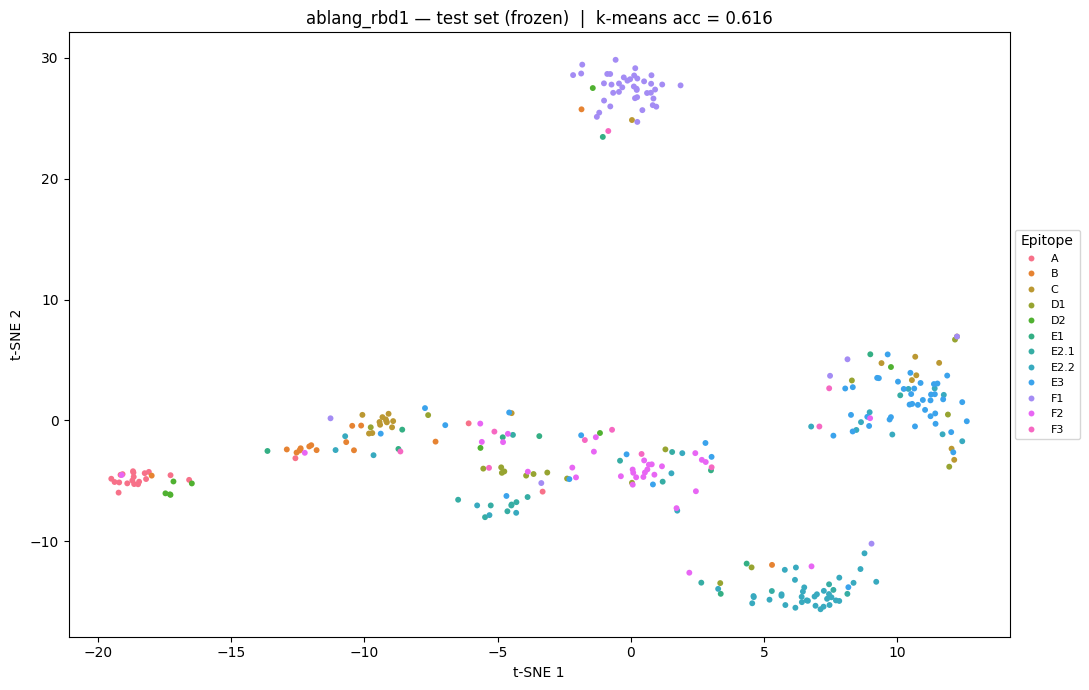

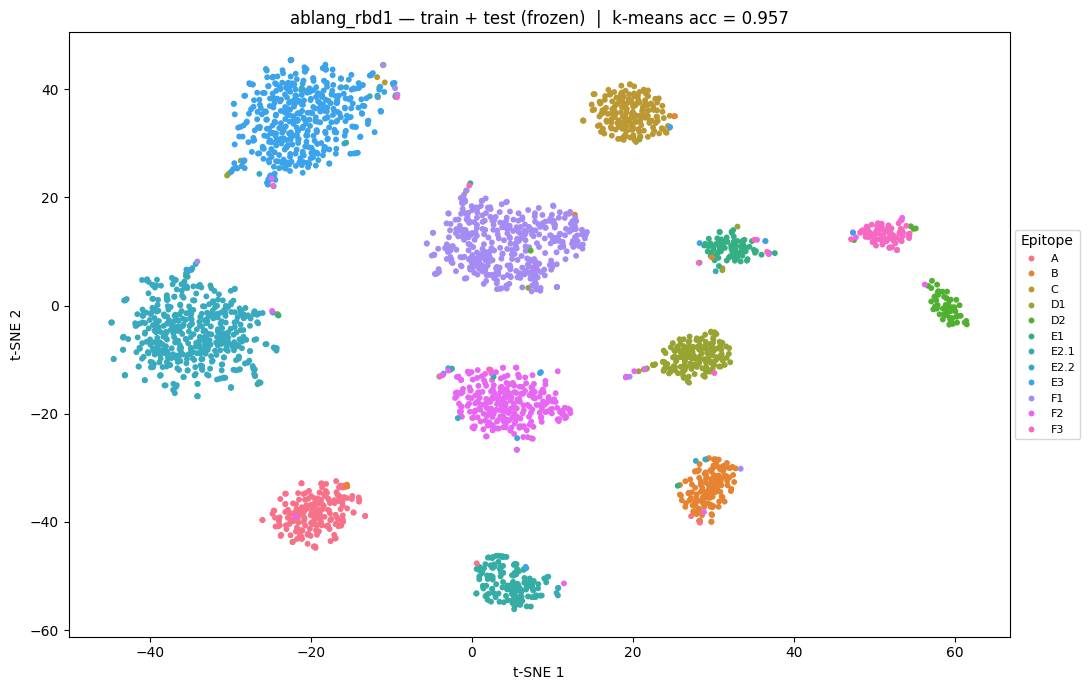

Saved → ../results/frozen_fixed/ablang_rbd1_cosine_distributions.png


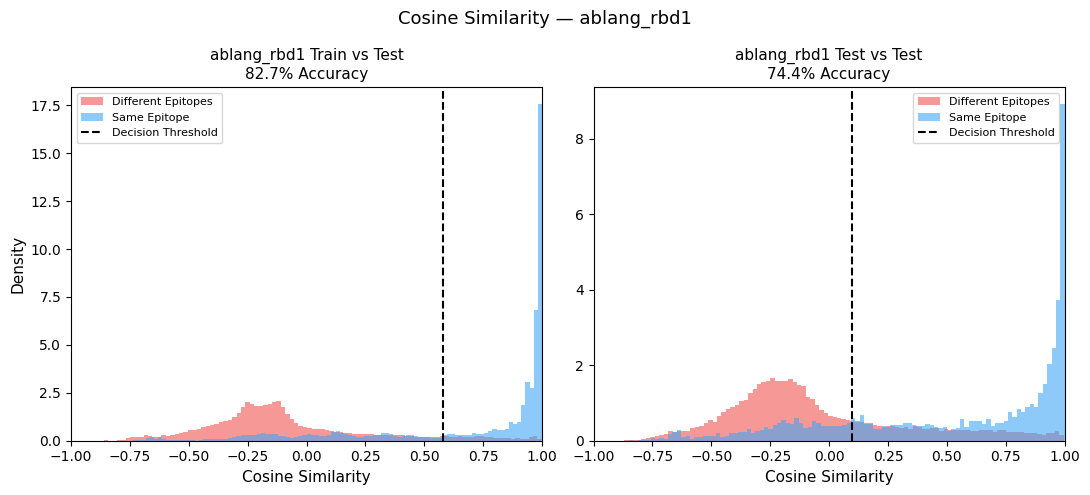

Saved → ../results/frozen_fixed/ablang_rbd1_final_eval.json
{
  "val_threshold": 0.51,
  "train_vs_test": {
    "average_precision": 0.7310572816070144,
    "f1": 0.6089382778029871,
    "balanced_accuracy": 0.8249010316424114,
    "threshold": 0.51,
    "weighted_auroc": 0.9028766300094468
  },
  "test_vs_test": {
    "average_precision": 0.5325693646659968,
    "f1": 0.46445137251920005,
    "balanced_accuracy": 0.7349907296238726,
    "threshold": 0.51,
    "weighted_auroc": 0.8204182225710182
  },
  "tsne_test": {
    "kmeans_accuracy": 0.6156351791530945
  },
  "tsne_train_test": {
    "kmeans_accuracy": 0.9570707070707071
  }
}

Evaluating: antiberty_frozen


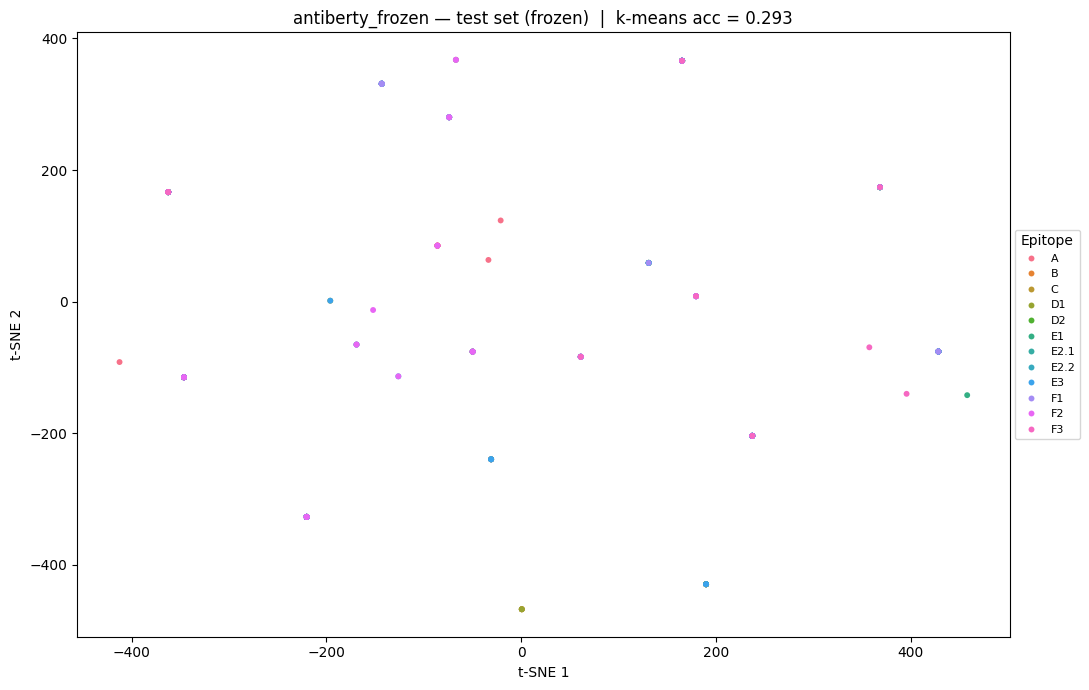

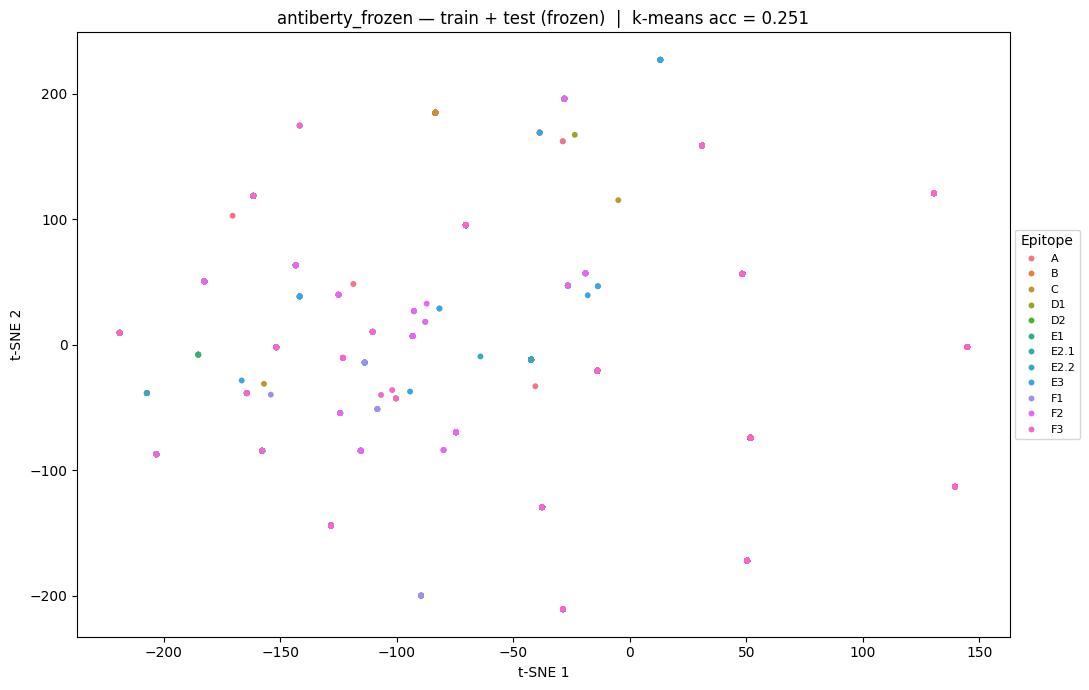

Saved → ../results/frozen_fixed/antiberty_frozen_cosine_distributions.png


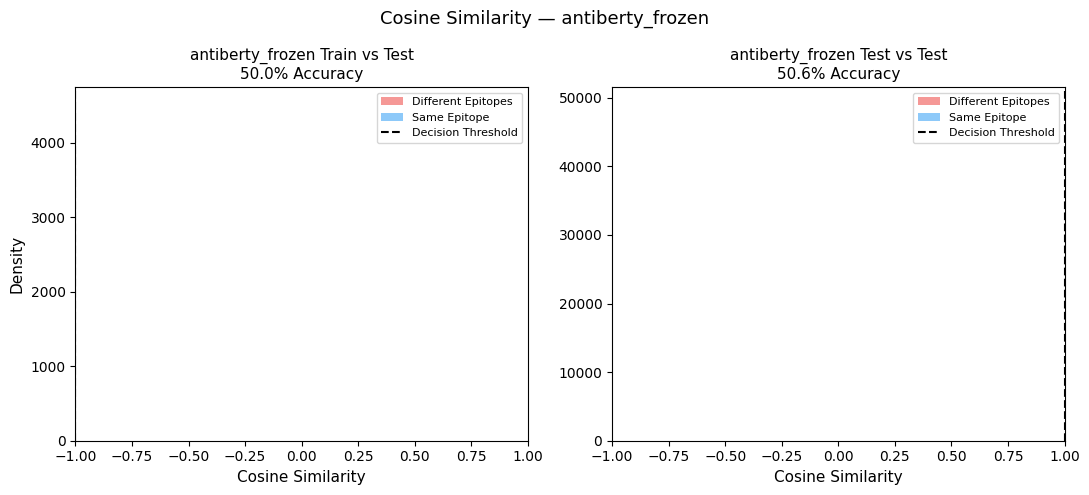

Saved → ../results/frozen_fixed/antiberty_frozen_final_eval.json
{
  "val_threshold": -0.014000000000000012,
  "train_vs_test": {
    "average_precision": 0.11095856745111309,
    "f1": 0.20320559774627556,
    "balanced_accuracy": 0.5,
    "threshold": -0.014000000000000012,
    "weighted_auroc": 0.49360247396491674
  },
  "test_vs_test": {
    "average_precision": 0.12608448932307376,
    "f1": 0.19937897722916506,
    "balanced_accuracy": 0.5,
    "threshold": -0.014000000000000012,
    "weighted_auroc": 0.5039639811567904
  },
  "tsne_test": {
    "kmeans_accuracy": 0.2931596091205212
  },
  "tsne_train_test": {
    "kmeans_accuracy": 0.2510822510822511
  }
}

Evaluating: esm2_frozen


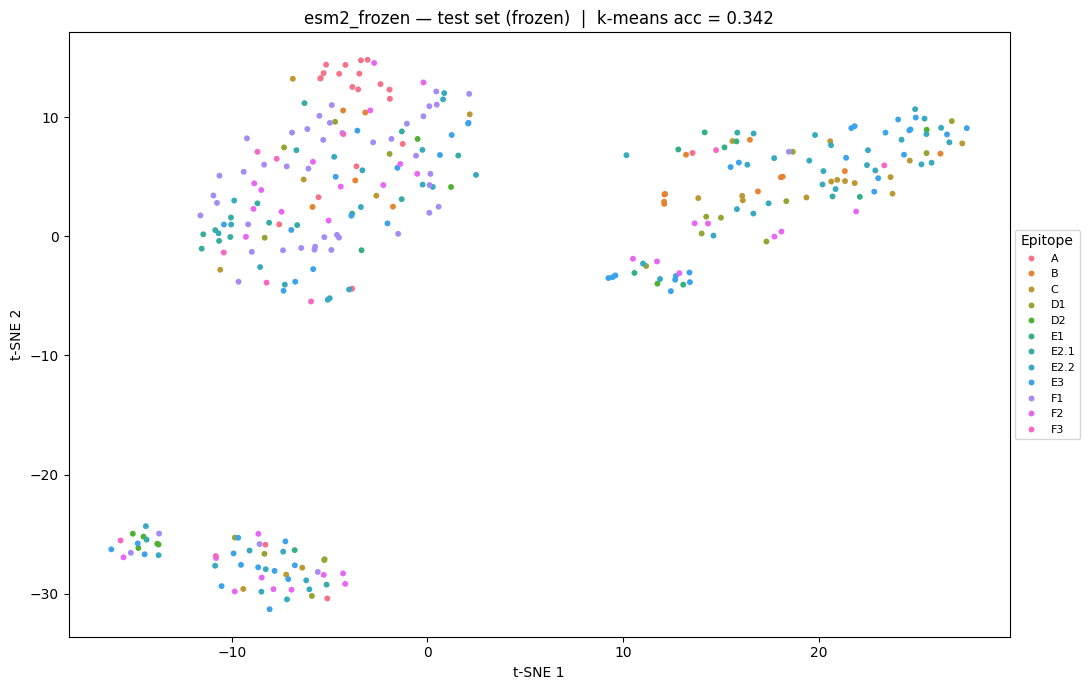

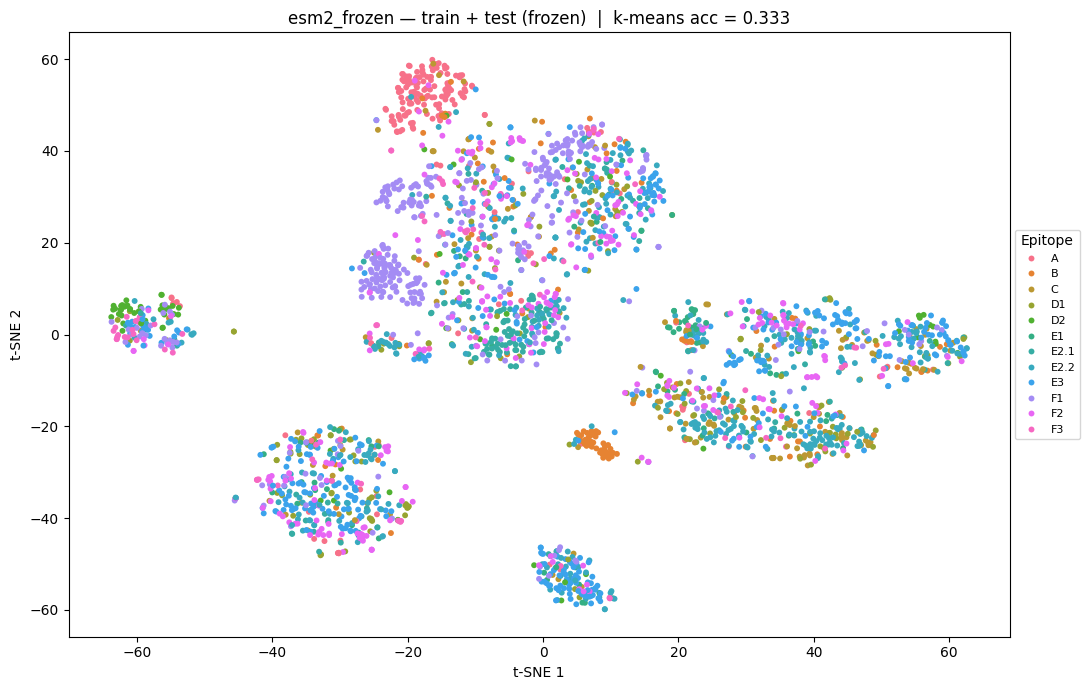

Saved → ../results/frozen_fixed/esm2_frozen_cosine_distributions.png


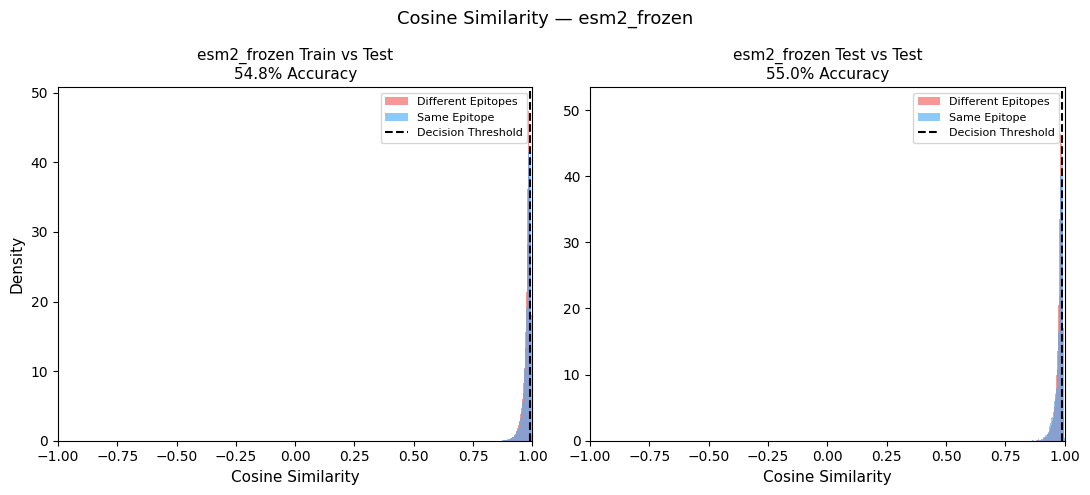

Saved → ../results/frozen_fixed/esm2_frozen_final_eval.json
{
  "val_threshold": 0.988,
  "train_vs_test": {
    "average_precision": 0.15772620936286003,
    "f1": 0.20720691208386224,
    "balanced_accuracy": 0.5484911673717776,
    "threshold": 0.988,
    "weighted_auroc": 0.5477957066620647
  },
  "test_vs_test": {
    "average_precision": 0.14959570147951853,
    "f1": 0.2066415877545726,
    "balanced_accuracy": 0.5499116415477273,
    "threshold": 0.988,
    "weighted_auroc": 0.5502020197129561
  },
  "tsne_test": {
    "kmeans_accuracy": 0.34201954397394135
  },
  "tsne_train_test": {
    "kmeans_accuracy": 0.3333333333333333
  }
}


In [31]:
import json
from pathlib import Path

# AbLang embeddings for train/val/test (pre-computed in rbd_dataset.pd)
ablang_frozen_train = F.normalize(torch.tensor(
    np.stack(df_train["EMBEDDING"].values), dtype=torch.float32), dim=1)
ablang_frozen_val = F.normalize(torch.tensor(
    np.stack(df_val["EMBEDDING"].values), dtype=torch.float32), dim=1)

ablang_ft_train = F.normalize(torch.tensor(
    np.stack(df_finetuned[df_finetuned["DATASET"] == "TRAIN"]["EMBEDDING"].values),
    dtype=torch.float32), dim=1)
ablang_ft_val = F.normalize(torch.tensor(
    np.stack(df_finetuned[df_finetuned["DATASET"] == "VAL"]["EMBEDDING"].values),
    dtype=torch.float32), dim=1)

frozen_models = {
    "ablang_frozen":    (ablang_frozen_train, ablang_frozen_val, ablang_frozen_embeddings),
    "ablang_rbd1":      (ablang_ft_train, ablang_ft_val, ablang_finetuned_embeddings),
    "antiberty_frozen": (ab_train_emb, ab_val_emb, ab_test_emb),
    "esm2_frozen":      (esm_train_emb, esm_val_emb, esm_test_emb),
}

frozen_results = {}
output_base = Path(os.pardir) / "results" / "frozen_fixed"
output_base.mkdir(parents=True, exist_ok=True)

for name, (train_emb, val_emb, test_emb) in frozen_models.items():
    print(f"\n{'='*60}")
    print(f"Evaluating: {name}")
    print(f"{'='*60}")

    metrics = evaluate_embedding_sets(
        train_emb, train_labels,
        val_emb, val_labels,
        test_emb, labels,  # `labels` = test labels from cell 2
    )

    # t-SNE: test set
    tsne_test = plot_tsne(
        test_emb, labels,
        title=f"{name} — test set (frozen)",
        perplexity=30,
        save_path=output_base / f"{name}_tsne_test.png",
    )
    metrics["tsne_test"] = tsne_test

    # t-SNE: train + test combined
    combined_emb = torch.cat([train_emb, test_emb], dim=0)
    combined_labels = np.concatenate([train_labels, labels])
    tsne_combined = plot_tsne(
        combined_emb, combined_labels,
        title=f"{name} — train + test (frozen)",
        perplexity=30,
        save_path=output_base / f"{name}_tsne_train_test.png",
    )
    metrics["tsne_train_test"] = tsne_combined

    # Cosine similarity distributions (Holt et al. Figure 3A style)
    y_true_tvt, y_score_tvt = _binary_pair_scores(
        train_emb, train_labels, test_emb, labels, same_dataset=False,
    )
    y_true_tt, y_score_tt = _binary_pair_scores(
        test_emb, labels, test_emb, labels, same_dataset=True,
    )
    plot_cosine_distributions(
        {
            f"{name} Train vs Test": (y_true_tvt, y_score_tvt),
            f"{name} Test vs Test": (y_true_tt, y_score_tt),
        },
        title=f"Cosine Similarity — {name}",
        save_path=output_base / f"{name}_cosine_distributions.png",
    )

    frozen_results[name] = metrics

    out_path = output_base / f"{name}_final_eval.json"
    out_path.write_text(json.dumps(metrics, indent=2) + "\n")
    print(f"Saved → {out_path}")
    print(json.dumps(metrics, indent=2))

### 10d. Full Comparison Table (Per-Epitope Weighted AUROC)

All six models — AbLang (frozen), AbLangRBD1 (Holt et al. fine-tuned), AntiBERTy, ESM-2, and our fine-tuned variants — evaluated with the same Holt et al. per-epitope weighted AUROC protocol. Saved as a figure for the paper.

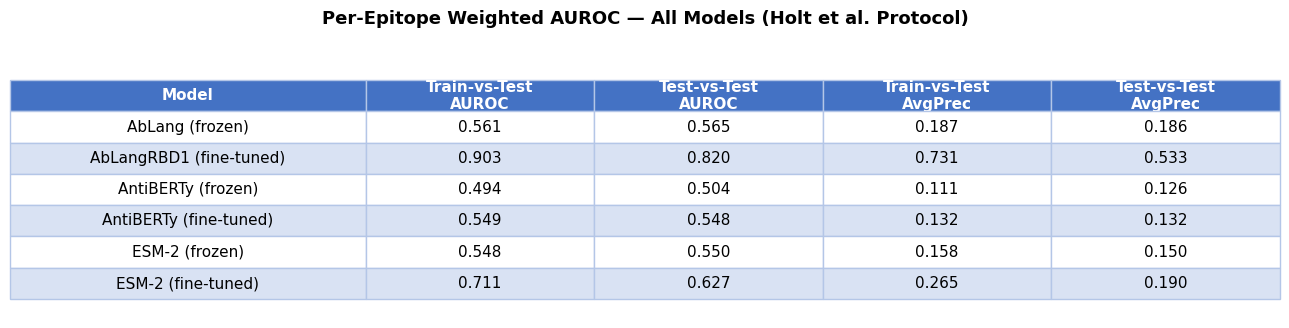

Saved → ../results/frozen_fixed/comparison_table.png


In [32]:
finetuned_paths = {
    "antiberty_finetuned": Path(os.pardir) / "results" / "antiberty_results" / "final_eval.json",
    "esm2_finetuned":      Path(os.pardir) / "results" / "esm2_results" / "final_eval.json",
}

finetuned_results = {}
for name, path in finetuned_paths.items():
    if path.exists():
        finetuned_results[name] = json.loads(path.read_text())
    else:
        print(f"⚠ {path} not found — skipping")

rows_data = [
    ("AbLang (frozen)",        frozen_results.get("ablang_frozen")),
    ("AbLangRBD1 (fine-tuned)", frozen_results.get("ablang_rbd1")),
    ("AntiBERTy (frozen)",     frozen_results.get("antiberty_frozen")),
    ("AntiBERTy (fine-tuned)", finetuned_results.get("antiberty_finetuned")),
    ("ESM-2 (frozen)",         frozen_results.get("esm2_frozen")),
    ("ESM-2 (fine-tuned)",     finetuned_results.get("esm2_finetuned")),
]

col_labels = ["Model", "Train-vs-Test\nAUROC", "Test-vs-Test\nAUROC",
              "Train-vs-Test\nAvgPrec", "Test-vs-Test\nAvgPrec"]
cell_text = []
for label, m in rows_data:
    if m is None:
        cell_text.append([label, "—", "—", "—", "—"])
        continue
    tvt = m.get("train_vs_test", {})
    tt  = m.get("test_vs_test", {})
    cell_text.append([
        label,
        f"{tvt.get('weighted_auroc', float('nan')):.3f}",
        f"{tt.get('weighted_auroc', float('nan')):.3f}",
        f"{tvt.get('average_precision', float('nan')):.3f}",
        f"{tt.get('average_precision', float('nan')):.3f}",
    ])

fig, ax = plt.subplots(figsize=(13, 3.2))
ax.axis("off")

table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)

# Widen the Model column (col 0) and give metric columns more room
col_widths = {0: 0.28, 1: 0.18, 2: 0.18, 3: 0.18, 4: 0.18}
for (row, col), cell in table.get_celld().items():
    if col in col_widths:
        cell.set_width(col_widths[col])
    if row == 0:
        cell.set_facecolor("#4472C4")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#D9E2F3")
    else:
        cell.set_facecolor("#FFFFFF")
    cell.set_edgecolor("#B4C6E7")

fig.suptitle("Per-Epitope Weighted AUROC — All Models (Holt et al. Protocol)",
             fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()

table_path = output_base / "comparison_table.png"
fig.savefig(table_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved → {table_path}")